<a href="https://colab.research.google.com/github/andrebrandaopro/machinelearning/blob/Portf%C3%B3lio/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.0 An end-to-end classification problem (Training)



## 1.1 Dataset description

We'll be looking at individual income in the United States. The **data** is from the **1994 census**, and contains information on an individual's **marital status**, **age**, **type of work**, and more. The **target column**, or what we want to predict, is whether individuals make less than or equal to 50k a year, or more than **50k a year**.

You can download the data from the [University of California, Irvine's website](http://archive.ics.uci.edu/ml/datasets/Adult).

Let's take the following steps:

1. ETL (done)
2. Data Checks (done)
3. Data Segregation (done)
4. Training

<center><img width="800" src="https://drive.google.com/uc?export=view&id=13kfVPzq-Jy-kH6GcJRfB44lIYAu5mtGl"></center>


## 1.2 Install, load libraries

In [115]:
!pip install wandb

In [116]:
import logging
import wandb
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import fbeta_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [117]:
# Login to Weights & Biases
!wandb login --relogin

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit: 
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


## 1.3 Holdout Configuration

<center><img width="800" src="https://drive.google.com/uc?export=view&id=1C2SEVnhyEd_lBpdTuwL3aTxNXh5-ktVX"></center>

In [118]:
# global variables

# ratio used to split train and validation data
val_size = 0.30

# seed used to reproduce purposes
seed = 41

# reference (column) to stratify the data
stratify = "high_income"

# name of the input artifact
artifact_input_name = "decision_tree/train.csv:latest"

# type of the artifact
artifact_type = "Train"

In [119]:
# configure logging
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s %(message)s",
                    datefmt='%d-%m-%Y %H:%M:%S')

# reference for a logging obj
logger = logging.getLogger()

# initiate the wandb project
run = wandb.init(project="decision_tree",job_type="train")

logger.info("Downloading and reading train artifact")
local_path = run.use_artifact(artifact_input_name).file()
df_train = pd.read_csv(local_path)

# Spliting train.csv into train and validation dataset
logger.info("Spliting data into train/val")
# split-out train/validation and test dataset
x_train, x_val, y_train, y_val = train_test_split(df_train.drop(labels=stratify,axis=1),
                                                  df_train[stratify],
                                                  test_size=val_size,
                                                  random_state=seed,
                                                  shuffle=True,
                                                  stratify=df_train[stratify])

In [120]:
logger.info("x train: {}".format(x_train.shape))
logger.info("y train: {}".format(y_train.shape))
logger.info("x val: {}".format(x_val.shape))
logger.info("y val: {}".format(y_val.shape))

## 1.4 Data preparation

**Data preparation** may be the most important part of a machine learning project.

```
It is the most time-consuming part, although it seems to be the least discussed topic.
```

**Data preparation** sometimes referred to as **data preprocessing**, is the act of transforming raw data into a form that is appropriate for modeling.

Machine learning algorithms require input data to be numbered, and most algorithm implementations maintain this expectation. As such, **if your data contains data types and values that are not numbers, such as labels, you will need to change the data into numbers**. Further, specific machine learning algorithms have expectations regarding the data types, scale, probability distribution, and relationships between input variables, and you may need to change the data to meet these expectations.

The philosophy of **data preparation** is to discover how to best expose the unknown underlying structure of the problem to the learning algorithms. This often requires **an iterative path of experimentation through a suite of different data preparation techniques** in order to discover what works well or best. The vast majority of the machine learning algorithms you may use on a project are years to decades old. **The implementation and application of the algorithms are well understood**. So much so that they are routine, with amazing, fully-featured open-source machine learning libraries like [scikit-learn](https://scikit-learn.org/stable/) in Python.
```
The thing that is different from project to project is the data.
```

You may be the first person (ever!) to use a specific dataset as the basis for a predictive modeling project. As such, the **preparation of the data** in order to best present it to the problem of the learning algorithms **is the primary task of any modern machine learning project**.

````
The challenge of data preparation is that each dataset is unique and different.
````

Datasets differ in the number of variables (tens, hundreds, thousands, or more), the types of the variables (numeric, nominal, ordinal, boolean), the scale of the variables, the drift in the values over time, and more. As such, this makes discussing data preparation a challenge. Either specific case studies are used, or focus is put on the general methods that can be used across projects. The result is that neither approach is explored.

### 1.4.1 Outlier Removal


<center><img width="800" src="https://drive.google.com/uc?export=view&id=1FMN6clRy5WuUPirbNStWFTk3LnxakWWW"></center>

In [121]:
logger.info("Outlier Removal")
# temporary variable
x = x_train.select_dtypes("int64").copy()

# identify outlier in the dataset
lof = LocalOutlierFactor()
outlier = lof.fit_predict(x)
mask = outlier != -1

In [122]:
logger.info("x_train shape [original]: {}".format(x_train.shape))
logger.info("x_train shape [outlier removal]: {}".format(x_train.loc[mask,:].shape))

In [123]:
# AVOID data leakage and you should not do this procedure in the preprocessing stage
# Note that we did not perform this procedure in the validation set
x_train = x_train.loc[mask,:].copy()
y_train = y_train[mask].copy()

### 1.4.2 Encoding Target Variable

<center><img width="800" src="https://drive.google.com/uc?export=view&id=1oigyMuJiI5gGb9V185y_GN9skS0BRy5Y"></center>

In [124]:
y_train.head(10)

,high_income
111,<=50K
22049,<=50K
1080,<=50K
22186,<=50K
6028,<=50K
17927,<=50K
9116,>50K
17130,<=50K
19845,<=50K
9562,<=50K


In [125]:
logger.info("Encoding Target Variable")
# define a categorical encoding for target variable
le = LabelEncoder()

# fit and transform y_train
y_train = le.fit_transform(y_train)

# transform y_test (avoiding data leakage)
y_val = le.transform(y_val)

logger.info("Classes [0, 1]: {}".format(le.inverse_transform([0, 1])))

In [126]:
y_train

array([0, 0, 0, ..., 0, 0, 0])

In [127]:
y_val

array([0, 0, 0, ..., 0, 0, 0])

### 1.4.3 Encoding independent variables [Experiment]


In [128]:
x_train.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
111,47,Private,344157,11th,7,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
22049,47,Private,72880,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States
1080,44,Self-emp-inc,195124,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,60,?
22186,58,Federal-gov,30111,Some-college,10,Widowed,Prof-specialty,Unmarried,Amer-Indian-Eskimo,Female,0,0,40,United-States
6028,36,Private,162424,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,45,United-States


In [129]:
x_train.workclass.unique()

array([' Private', ' Self-emp-inc', ' Federal-gov', ' State-gov',
       ' Local-gov', ' Self-emp-not-inc', ' ?', ' Without-pay',
       ' Never-worked'], dtype=object)

In [130]:
x_train["sex"].values.shape

(14694,)

In [131]:
x_train["sex"].values.reshape(-1,1).shape

(14694, 1)

In [132]:
# just an experimentation

# drop=first erase redundant column
onehot = OneHotEncoder(drop="first")

# fit using x_train
onehot.fit(x_train["sex"].values.reshape(-1,1))

# make a copy
x_train_aux = x_train.copy()

# transform train
x_train_aux[onehot.get_feature_names_out()] = onehot.transform(x_train_aux["sex"].values.reshape(-1,1))
x_train_aux.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,x0_ Male
111,47,Private,344157,11th,7,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<Compressed Sparse Row sparse matrix of dtype ...
22049,47,Private,72880,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,40,United-States,<Compressed Sparse Row sparse matrix of dtype ...
1080,44,Self-emp-inc,195124,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,60,?,<Compressed Sparse Row sparse matrix of dtype ...
22186,58,Federal-gov,30111,Some-college,10,Widowed,Prof-specialty,Unmarried,Amer-Indian-Eskimo,Female,0,0,40,United-States,<Compressed Sparse Row sparse matrix of dtype ...
6028,36,Private,162424,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,45,United-States,<Compressed Sparse Row sparse matrix of dtype ...


In [133]:
# Inverse transformation
onehot.inverse_transform(np.array([0,1]).reshape(-1,1))

array([[' Female'],
       [' Male']], dtype=object)

In [134]:
# Inverse transformation (other way)
onehot.inverse_transform([[0],[1]])

array([[' Female'],
       [' Male']], dtype=object)

In [135]:
# Return the name of the new feature
onehot.get_feature_names_out()

array(['x0_ Male'], dtype=object)

### 1.4.4 Encoding independent variables

In [136]:
# Show the shape of x train before transformation
x_train.shape

(14694, 14)

In [137]:
# Lets review what are categorical columns
x_train.select_dtypes("object").columns.to_list()

['workclass',
 'education',
 'marital_status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native_country']

In [138]:
# 08 columns are "object", lets transform them to categorical
for name in x_train.select_dtypes("object").columns.to_list():
    onehot = OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore') # handle_unknown='ignore' to avoid errors with unseen values during transform
    # fit using x_train
    onehot.fit(x_train[[name]]) # Fit on a DataFrame for consistent column handling

    # transform train and validation
    encoded_data_train = onehot.transform(x_train[[name]])
    encoded_data_val = onehot.transform(x_val[[name]])

    # Create new column names
    new_cols_train = [f"{name}_{cat}" for cat in onehot.categories_[0][1:]]
    new_cols_val = [f"{name}_{cat}" for cat in onehot.categories_[0][1:]]

    # Add encoded columns to the DataFrames
    x_train = pd.concat([x_train, pd.DataFrame(encoded_data_train, columns=new_cols_train, index=x_train.index)], axis=1)
    x_val = pd.concat([x_val, pd.DataFrame(encoded_data_val, columns=new_cols_val, index=x_val.index)], axis=1)

In [139]:
x_train.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,native_country_ Portugal,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia
111,47,Private,344157,11th,7,Divorced,Handlers-cleaners,Not-in-family,White,Male,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22049,47,Private,72880,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1080,44,Self-emp-inc,195124,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22186,58,Federal-gov,30111,Some-college,10,Widowed,Prof-specialty,Unmarried,Amer-Indian-Eskimo,Female,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6028,36,Private,162424,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [140]:
x_val.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,native_country_ Portugal,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia
8819,19,Private,472807,1st-4th,2,Never-married,Handlers-cleaners,Other-relative,White,Male,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3807,41,Self-emp-not-inc,223763,Masters,14,Married-civ-spouse,Craft-repair,Husband,White,Male,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14150,33,Private,133278,HS-grad,9,Never-married,Adm-clerical,Own-child,Black,Female,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18800,44,Private,162643,HS-grad,9,Never-married,Adm-clerical,Not-in-family,White,Female,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
20818,23,Private,156513,HS-grad,9,Never-married,Handlers-cleaners,Own-child,Black,Male,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [141]:
cols=['workclass','education','marital_status','occupation',
      'relationship','race','sex','native_country']

x_train.drop(labels=cols,axis=1,inplace=True)
x_val.drop(labels=cols,axis=1,inplace=True)

In [142]:
x_train.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native_country_ Portugal,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia
111,47,344157,7,0,0,40,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22049,47,72880,14,0,0,40,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1080,44,195124,9,0,0,60,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22186,58,30111,10,0,0,40,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6028,36,162424,9,0,0,45,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [143]:
x_val.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native_country_ Portugal,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia
8819,19,472807,2,0,0,52,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3807,41,223763,14,0,0,65,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
14150,33,133278,9,0,0,40,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18800,44,162643,9,0,0,43,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
20818,23,156513,9,0,0,40,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In thesis, after this encoding process the dataset is ready to be trained.

### 1.4.5 Using a full-pipeline

```
A reproducible pipeline is all you need
```

To follow the next cells' execution, it is important you re-run all cells at:
- Section 1.3
- Section 1.4.1
- Section 1.4.2

These steps are necessary to guarantee the raw ```train.csv``` is used.

#### 1.4.5.1 Feature Extractor

In [144]:
class FeatureSelector(BaseEstimator, TransformerMixin):
    # Class Constructor
    def __init__(self, feature_names):
        self.feature_names = feature_names

    # Return self nothing else to do here
    def fit(self, X, y=None):
        return self

    # Method that describes what this custom transformer need to do
    def transform(self, X, y=None):
        return X[self.feature_names]

In [145]:
# for validation purposes
fs = FeatureSelector(x_train.select_dtypes("object").columns.to_list())
df = fs.fit_transform(x_train)
df.head()

""
111
22049
1080
22186
6028


In [146]:
# for validation purposes
fs = FeatureSelector(x_train.select_dtypes("int64").columns.to_list())
df = fs.fit_transform(x_train)
df.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
111,47,344157,7,0,0,40
22049,47,72880,14,0,0,40
1080,44,195124,9,0,0,60
22186,58,30111,10,0,0,40
6028,36,162424,9,0,0,45


#### 1.4.5.2 Handling Categorical Features

In [147]:
class CategoricalTransformer(BaseEstimator, TransformerMixin):
    # Class constructor method that takes one boolean as its argument
    def __init__(self, new_features=True, colnames=None):
        self.new_features = new_features
        self.colnames = colnames

    # Return self nothing else to do here
    def fit(self, X, y=None):
        return self

    # Handle case where colnames is None
    def get_feature_names_out(self):
        return self.colnames.tolist() if self.colnames else None

    # Transformer method we wrote
    def transform(self, X, y=None):
        # Convert columns to numerical using pd.factorize
        X = X.apply(lambda x: pd.factorize(x)[0])

        return X

In [148]:
original_categorical_cols = [col for col in x_train.columns if col.startswith('workclass_') or
                             col.startswith('education_') or
                             col.startswith('marital_status_') or
                             col.startswith('occupation_') or
                             col.startswith('relationship_') or
                             col.startswith('race_') or
                             col.startswith('sex_') or
                             col.startswith('native_country_')]
fs = FeatureSelector(original_categorical_cols)
df = fs.fit_transform(x_train)
df.head()

,education_num,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,workclass_ Without-pay,education_ 11th,...,native_country_ Portugal,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia
111,7,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22049,14,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1080,9,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22186,10,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
6028,9,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [149]:
# for validation purposes
ct = CategoricalTransformer(new_features=True,colnames=df.columns.tolist())
df_cat = ct.fit_transform(df)
df_cat.head()

,education_num,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,workclass_ Without-pay,education_ 11th,...,native_country_ Portugal,native_country_ Puerto-Rico,native_country_ Scotland,native_country_ South,native_country_ Taiwan,native_country_ Thailand,native_country_ Trinadad&Tobago,native_country_ United-States,native_country_ Vietnam,native_country_ Yugoslavia
111,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22049,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1080,2,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
22186,3,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
6028,2,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [150]:
# check the cardinality before and after transformation
x_train.select_dtypes("object").apply(pd.Series.nunique)

,0


In [151]:
# check the cardinality before and after transformation
df_cat.apply(pd.Series.nunique)

,0
education_num,16
workclass_ Federal-gov,2
workclass_ Local-gov,2
workclass_ Never-worked,2
workclass_ Private,2
...,...
native_country_ Thailand,2
native_country_ Trinadad&Tobago,2
native_country_ United-States,2
native_country_ Vietnam,2


#### 1.4.5.3 Handling Numerical Features

In [152]:
# transform numerical features
class NumericalTransformer(BaseEstimator, TransformerMixin):
    # Class constructor method that takes a model parameter as its argument
    # model 0: minmax
    # model 1: standard
    # model 2: without scaler
    def __init__(self, model=0, colnames=None):
        self.model = model
        self.colnames = colnames
        self.scaler = None

    # Fit is used only to learn statistical about Scalers
    def fit(self, X, y=None):
        df = pd.DataFrame(X, columns=self.colnames)
        # minmax
        if self.model == 0:
            self.scaler = MinMaxScaler()
            self.scaler.fit(df)
        # standard scaler
        elif self.model == 1:
            self.scaler = StandardScaler()
            self.scaler.fit(df)
        return self

    # return columns names after transformation
    def get_feature_names_out(self):
        return self.colnames

    # Transformer method we wrote for this transformer
    # Use fitted scalers
    def transform(self, X, y=None):
        df = pd.DataFrame(X, columns=self.colnames)

        # update columns name
        self.colnames = df.columns.tolist()

        # minmax
        if self.model == 0:
            # transform data
            df = self.scaler.transform(df)
        elif self.model == 1:
            # transform data
            df = self.scaler.transform(df)
        else:
            df = df.values

        return df

In [153]:
# for validation purposes
fs = FeatureSelector(x_train.select_dtypes("int64").columns.to_list())
df = fs.fit_transform(x_train)
df.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
111,47,344157,7,0,0,40
22049,47,72880,14,0,0,40
1080,44,195124,9,0,0,60
22186,58,30111,10,0,0,40
6028,36,162424,9,0,0,45


In [154]:
# for validation purposes
nt = NumericalTransformer(model=1)
df_num = nt.fit_transform(df)
df_num

array([[ 0.63957248,  1.51617318, -1.1786716 , -0.12191786, -0.07207142,
        -0.02441449],
       [ 0.63957248, -1.12981702,  1.55741062, -0.12191786, -0.07207142,
        -0.02441449],
       [ 0.41790699,  0.06253038, -0.39693382, -0.12191786, -0.07207142,
         1.60625118],
       ...,
       [ 1.74789994, -0.28096056, -0.00606493, -0.12191786, -0.07207142,
        -1.98121328],
       [-0.83819747,  0.18761352, -0.00606493, -0.12191786, -0.07207142,
        -0.02441449],
       [ 0.49179548,  1.60254336, -0.39693382, -0.12191786, -0.07207142,
        -0.02441449]])

In [155]:
# return columns name
nt.get_feature_names_out()

['age',
 'fnlwgt',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

#### 1.4.5.4 Data Preparation Pipeline

In [167]:
# model = 0 (min-max), 1 (z-score), 2 (without normalization)
numerical_model = 0

# Update categorical_features to include the one-hot encoded columns
categorical_features = [col for col in x_train.columns if col.startswith('workclass_') or
                             col.startswith('education_') or
                             col.startswith('marital_status_') or
                             col.startswith('occupation_') or
                             col.startswith('relationship_') or
                             col.startswith('race_') or
                             col.startswith('sex_') or
                             col.startswith('native_country_')]

# Numerical features to pass down the numerical pipeline
numerical_features = x_train.select_dtypes("int64").columns.to_list()

# Defining the steps for the categorical pipeline
categorical_pipeline = Pipeline(steps=[('cat_selector', FeatureSelector(categorical_features)),
                                       ('imputer_cat', SimpleImputer(strategy="most_frequent")),
                                       ('cat_encoder', OneHotEncoder(sparse_output=False, drop="first", handle_unknown='ignore'))
                                       ]
                                )

# Defining the steps in the numerical pipeline
numerical_pipeline = Pipeline(steps=[('num_selector', FeatureSelector(numerical_features)),
                                     ('imputer_num', SimpleImputer(strategy="median")),
                                     ('num_transformer', NumericalTransformer(numerical_model,
                                                                              colnames=numerical_features))])

# Combine numerical and categorical pieplines into one full big pipeline horizontally
full_pipeline_preprocessing = FeatureUnion(transformer_list=[('cat_pipeline', categorical_pipeline),
                                                             ('num_pipeline', numerical_pipeline)]
                                           )

In [157]:
# for validation purposes
new_data = full_pipeline_preprocessing.fit_transform(x_train)
# cat_names is a numpy array
cat_names = full_pipeline_preprocessing.get_params()["cat_pipeline"][2].get_feature_names_out().tolist() # Changed index from 3 to 2
# num_names is a list
num_names = full_pipeline_preprocessing.get_params()["num_pipeline"][2].get_feature_names_out()
df = pd.DataFrame(new_data,columns = cat_names + num_names)
df.head()

,x0_2.0,x0_3.0,x0_4.0,x0_5.0,x0_6.0,x0_7.0,x0_8.0,x0_9.0,x0_10.0,x0_11.0,...,x90_1.0,x91_1.0,x92_1.0,x93_1.0,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.410959,0.407434,0.400000,0.0,0.0,0.397959
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.410959,0.067290,0.866667,0.0,0.0,0.397959
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.369863,0.220567,0.533333,0.0,0.0,0.602041
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.561644,0.013663,0.600000,0.0,0.0,0.397959
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.260274,0.179566,0.533333,0.0,0.0,0.448980


## 1.5 Holdout Training

In this example the inference artifacts are:
- pipe (contains trained model and the preprocesing pipeline
- le (label encoder object used to encode the target variable)

In [158]:
# The full pipeline
pipe = Pipeline(steps = [('full_pipeline', full_pipeline_preprocessing),
                         ("classifier",DecisionTreeClassifier())
                         ]
                )

# training
logger.info("Training")
pipe.fit(x_train, y_train)

# predict
logger.info("Infering")
predict = pipe.predict(x_val)

# Evaluation Metrics
logger.info("Evaluation metrics")
fbeta = fbeta_score(y_val, predict, beta=1, zero_division=1)
precision = precision_score(y_val, predict, zero_division=1)
recall = recall_score(y_val, predict, zero_division=1)
acc = accuracy_score(y_val, predict)

logger.info("Accuracy: {}".format(acc))
logger.info("Precision: {}".format(precision))
logger.info("Recall: {}".format(recall))
logger.info("F1: {}".format(fbeta))

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [159]:
run.summary["Acc"] = acc
run.summary["Precision"] = precision
run.summary["Recall"] = recall
run.summary["F1"] = fbeta

In [160]:
# predict bias
logger.info("Infering Bias")
predict_bias = pipe.predict(x_train)

# Evaluation Metrics
logger.info("Bias Evaluation metrics")
fbeta = fbeta_score(y_train, predict_bias, beta=1, zero_division=1)
precision = precision_score(y_train, predict_bias, zero_division=1)
recall = recall_score(y_train, predict_bias, zero_division=1)
acc = accuracy_score(y_train, predict_bias)

logger.info("Bias Accuracy: {}".format(acc))
logger.info("Bias Precision: {}".format(precision))
logger.info("Bias Recall: {}".format(recall))
logger.info("Bias F1: {}".format(fbeta))

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [161]:
# Compare the accuracy, precision, recall with previous ones
print(classification_report(y_val,predict))

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      5187
           1       0.60      0.61      0.60      1646

    accuracy                           0.81      6833
   macro avg       0.74      0.74      0.74      6833
weighted avg       0.81      0.81      0.81      6833



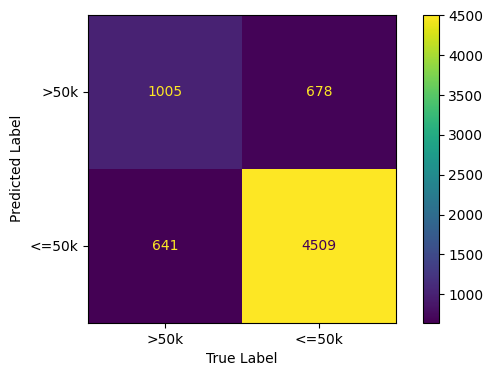

In [162]:
fig_confusion_matrix, ax = plt.subplots(1,1,figsize=(7,4))
ConfusionMatrixDisplay(confusion_matrix(predict,y_val,labels=[1,0]),
                       display_labels=[">50k","<=50k"]).plot(values_format=".0f",ax=ax)

ax.set_xlabel("True Label")
ax.set_ylabel("Predicted Label")
plt.show()

In [163]:
# Uploading figures
logger.info("Uploading figures")
run.log(
    {
        "confusion_matrix": wandb.Image(fig_confusion_matrix),
        # "other_figure": wandb.Image(other_fig)
    }
)

In [180]:
# Feature importance
pipe.get_params()["classifier"].feature_importances_

# Fit the full_pipeline_preprocessing to the training data if it hasn't been already
# This is crucial for the transform method to work correctly
full_pipeline_preprocessing.fit(x_train)

# Get categorical column names
cat_names = pipe.named_steps['full_pipeline'].get_params()["cat_pipeline"][2].get_feature_names_out().tolist() # Changed index from 3 to 2

# Get numerical column names
num_names = pipe.named_steps['full_pipeline'].get_params()["num_pipeline"][2].get_feature_names_out()

# merge all column names together
all_names = cat_names + num_names

# Visualize all classifier plots
# For a complete documentation please see: https://docs.wandb.ai/guides/integrations/scikit
wandb.sklearn.plot_classifier(pipe.get_params()["classifier"],
                              full_pipeline_preprocessing.transform(x_train),
                              full_pipeline_preprocessing.transform(x_val),
                              y_train,
                              y_val,
                              predict,
                              pipe.predict_proba(x_val),
                              [0,1],
                              model_name='DT', feature_names=all_names)

wandb: 
wandb: Plotting DT.
wandb: Logged feature importances.
wandb: Logged confusion matrix.
wandb: Logged summary metrics.
wandb: Logged class proportions.
wandb: Logged calibration curve.
wandb: Logged roc curve.
wandb: Logged precision-recall curve.


In [181]:
# Get categorical column names
cat_names = pipe.named_steps['full_pipeline'].get_params()["cat_pipeline"][2].get_feature_names_out().tolist() # Changed index from 3 to 2
cat_names

['x0_2.0',
 'x0_3.0',
 'x0_4.0',
 'x0_5.0',
 'x0_6.0',
 'x0_7.0',
 'x0_8.0',
 'x0_9.0',
 'x0_10.0',
 'x0_11.0',
 'x0_12.0',
 'x0_13.0',
 'x0_14.0',
 'x0_15.0',
 'x0_16.0',
 'x1_1.0',
 'x2_1.0',
 'x3_1.0',
 'x4_1.0',
 'x5_1.0',
 'x6_1.0',
 'x7_1.0',
 'x8_1.0',
 'x9_1.0',
 'x10_1.0',
 'x11_1.0',
 'x12_1.0',
 'x13_1.0',
 'x14_1.0',
 'x15_1.0',
 'x16_1.0',
 'x17_1.0',
 'x18_1.0',
 'x19_1.0',
 'x20_1.0',
 'x21_1.0',
 'x22_1.0',
 'x23_1.0',
 'x24_1.0',
 'x25_1.0',
 'x26_1.0',
 'x27_1.0',
 'x28_1.0',
 'x29_1.0',
 'x30_1.0',
 'x31_1.0',
 'x32_1.0',
 'x33_1.0',
 'x34_1.0',
 'x35_1.0',
 'x36_1.0',
 'x37_1.0',
 'x38_1.0',
 'x39_1.0',
 'x40_1.0',
 'x41_1.0',
 'x42_1.0',
 'x43_1.0',
 'x44_1.0',
 'x45_1.0',
 'x46_1.0',
 'x47_1.0',
 'x48_1.0',
 'x49_1.0',
 'x50_1.0',
 'x51_1.0',
 'x52_1.0',
 'x53_1.0',
 'x54_1.0',
 'x55_1.0',
 'x56_1.0',
 'x57_1.0',
 'x58_1.0',
 'x59_1.0',
 'x60_1.0',
 'x61_1.0',
 'x62_1.0',
 'x63_1.0',
 'x64_1.0',
 'x65_1.0',
 'x66_1.0',
 'x67_1.0',
 'x68_1.0',
 'x69_1.0',
 'x70_1.0

In [170]:
# Get numerical column names
num_names = pipe.named_steps['full_pipeline'].get_params()["num_pipeline"][2].get_feature_names_out()
num_names

['age',
 'fnlwgt',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

In [182]:
# merge all column names together
all_names = cat_names + num_names
all_names

['x0_2.0',
 'x0_3.0',
 'x0_4.0',
 'x0_5.0',
 'x0_6.0',
 'x0_7.0',
 'x0_8.0',
 'x0_9.0',
 'x0_10.0',
 'x0_11.0',
 'x0_12.0',
 'x0_13.0',
 'x0_14.0',
 'x0_15.0',
 'x0_16.0',
 'x1_1.0',
 'x2_1.0',
 'x3_1.0',
 'x4_1.0',
 'x5_1.0',
 'x6_1.0',
 'x7_1.0',
 'x8_1.0',
 'x9_1.0',
 'x10_1.0',
 'x11_1.0',
 'x12_1.0',
 'x13_1.0',
 'x14_1.0',
 'x15_1.0',
 'x16_1.0',
 'x17_1.0',
 'x18_1.0',
 'x19_1.0',
 'x20_1.0',
 'x21_1.0',
 'x22_1.0',
 'x23_1.0',
 'x24_1.0',
 'x25_1.0',
 'x26_1.0',
 'x27_1.0',
 'x28_1.0',
 'x29_1.0',
 'x30_1.0',
 'x31_1.0',
 'x32_1.0',
 'x33_1.0',
 'x34_1.0',
 'x35_1.0',
 'x36_1.0',
 'x37_1.0',
 'x38_1.0',
 'x39_1.0',
 'x40_1.0',
 'x41_1.0',
 'x42_1.0',
 'x43_1.0',
 'x44_1.0',
 'x45_1.0',
 'x46_1.0',
 'x47_1.0',
 'x48_1.0',
 'x49_1.0',
 'x50_1.0',
 'x51_1.0',
 'x52_1.0',
 'x53_1.0',
 'x54_1.0',
 'x55_1.0',
 'x56_1.0',
 'x57_1.0',
 'x58_1.0',
 'x59_1.0',
 'x60_1.0',
 'x61_1.0',
 'x62_1.0',
 'x63_1.0',
 'x64_1.0',
 'x65_1.0',
 'x66_1.0',
 'x67_1.0',
 'x68_1.0',
 'x69_1.0',
 'x70_1.0

In [183]:
# Visualize all classifier plots
# For a complete documentation please see: https://docs.wandb.ai/guides/integrations/scikit
wandb.sklearn.plot_classifier(pipe.get_params()["classifier"],
                              full_pipeline_preprocessing.transform(x_train),
                              full_pipeline_preprocessing.transform(x_val),
                              y_train,
                              y_val,
                              predict,
                              pipe.predict_proba(x_val),
                              [0,1],
                              model_name='DT', feature_names=all_names)

wandb: 
wandb: Plotting DT.
wandb: Logged feature importances.
wandb: Logged confusion matrix.
wandb: Logged summary metrics.
wandb: Logged class proportions.
wandb: Logged calibration curve.
wandb: Logged roc curve.
wandb: Logged precision-recall curve.


In [184]:
# Visualize single plot
wandb.sklearn.plot_confusion_matrix(y_val, predict, [0,1])

In [185]:
# Catch up the class proportions between train and validation
wandb.sklearn.plot_class_proportions(y_train, y_val, [0,1])

In [186]:
# Plot the importance of columns
wandb.sklearn.plot_feature_importances(pipe.get_params()["classifier"],all_names)

In [187]:
# Plot a brief summary of the weighted avg results (recall, precision, f1, acc)
wandb.sklearn.plot_summary_metrics(pipe.get_params()["classifier"],
                                    full_pipeline_preprocessing.transform(x_train),
                                    y_train,
                                    full_pipeline_preprocessing.transform(x_val),
                                    y_val)

In [188]:
# ROC curve
predict_proba = pipe.predict_proba(x_val)
wandb.sklearn.plot_roc(y_val, predict_proba, [0,1])

In [189]:
# close the current run before to execute the next section
run.finish()

Acc,0.80697
F1,0.60378
Precision,0.59715
Recall,0.61057


## 1.6 Hyperparameter Tuning

In [191]:
# To see all parameters of a specific step of the pipeline
pipe.named_steps['classifier'].get_params() #or
pipe.named_steps['full_pipeline'].get_params()

{'n_jobs': None,
 'transformer_list': [('cat_pipeline',
   Pipeline(steps=[('cat_selector',
                    FeatureSelector(feature_names=['education_num',
                                                   'workclass_ Federal-gov',
                                                   'workclass_ Local-gov',
                                                   'workclass_ Never-worked',
                                                   'workclass_ Private',
                                                   'workclass_ Self-emp-inc',
                                                   'workclass_ Self-emp-not-inc',
                                                   'workclass_ State-gov',
                                                   'workclass_ Without-pay',
                                                   'education_ 11th',
                                                   'education_ 12th',
                                                   'education_ 1st-4th',
            

In [192]:
# global seed
seed = 41

In [193]:
sweep_config = {
    # try grid or random
    "method": "random",
    "metric": {
        "name": "Accuracy",
        "goal": "maximize"
        },
    "parameters": {
        "criterion": {
            "values": ["gini","entropy"]
            },
        "splitter": {
            "values": ["random","best"]
        },
        "model": {
            "values": [0,1,2]
        },
        "random_state": {
            "values": [seed]
        }
    }
}

sweep_id = wandb.sweep(sweep_config, project="decision_tree")

Create sweep with ID: zpa7xz5h
Sweep URL: https://wandb.ai/andre-brandao-067-ufrn/decision_tree/sweeps/zpa7xz5h


In [194]:
def train():
    with wandb.init() as run:

        # The full pipeline
        pipe = Pipeline(steps = [('full_pipeline', full_pipeline_preprocessing),
                                    ("classifier",DecisionTreeClassifier())
                                    ]
                        )

        # update the parameters of the pipeline that we would like to tuning
        pipe.set_params(**{"full_pipeline__num_pipeline__num_transformer__model": run.config.model})
        pipe.set_params(**{"classifier__criterion": run.config.criterion})
        pipe.set_params(**{"classifier__splitter": run.config.splitter})
        pipe.set_params(**{"classifier__random_state": run.config.random_state})

        # training
        logger.info("Training")
        pipe.fit(x_train, y_train)

        # predict
        logger.info("Infering")
        predict = pipe.predict(x_val)

        # Evaluation Metrics
        logger.info("Evaluation metrics")
        fbeta = fbeta_score(y_val, predict, beta=1, zero_division=1)
        precision = precision_score(y_val, predict, zero_division=1)
        recall = recall_score(y_val, predict, zero_division=1)
        acc = accuracy_score(y_val, predict)

        logger.info("Accuracy: {}".format(acc))
        logger.info("Precision: {}".format(precision))
        logger.info("Recall: {}".format(recall))
        logger.info("F1: {}".format(fbeta))

        run.summary["Accuracy"] = acc
        run.summary["Precision"] = precision
        run.summary["Recall"] = recall
        run.summary["F1"] = fbeta

In [195]:
wandb.agent(sweep_id, train, count=8)

wandb: Agent Starting Run: rcp9jlhi with config:
wandb: 	criterion: entropy
wandb: 	model: 0
wandb: 	random_state: 41
wandb: 	splitter: best


Accuracy,0.81706
F1,0.62775
Precision,0.61565
Recall,0.64034


wandb: Agent Starting Run: 8qxcip0y with config:
wandb: 	criterion: gini
wandb: 	model: 0
wandb: 	random_state: 41
wandb: 	splitter: best


Accuracy,0.80872
F1,0.60786
Precision,0.60047
Recall,0.61543


wandb: Agent Starting Run: xrgu0zpk with config:
wandb: 	criterion: gini
wandb: 	model: 2
wandb: 	random_state: 41
wandb: 	splitter: best


...

Accuracy,0.80404
F1,0.60232
Precision,0.58919
Recall,0.61604


wandb: Agent Starting Run: 5o7b591g with config:
wandb: 	criterion: entropy
wandb: 	model: 0
wandb: 	random_state: 41
wandb: 	splitter: best


Accuracy,0.81706
F1,0.62775
Precision,0.61565
Recall,0.64034


wandb: Agent Starting Run: 0ks45859 with config:
wandb: 	criterion: gini
wandb: 	model: 1
wandb: 	random_state: 41
wandb: 	splitter: random


Accuracy,0.80404
F1,0.60232
Precision,0.58919
Recall,0.61604


## 1.7 Configure and train the best model

In [196]:
# Note that a new run is yet synced to last sweep run
# Just to check
run = wandb.init()

<font color="red">Important</font> to restart the colab to unlink a new experiment (run) with the last ```sweep``` experiment.

```
Runtime >> Factory reset runtime
```
> Re-run all cells except for: ```1.4.3```, ```1.4.4```, ```1.5``` and ```1.6```.

In [197]:
# initiate the wandb project
run = wandb.init(project="decision_tree",job_type="train")

In [198]:
# The full pipeline
pipe = Pipeline(steps = [('full_pipeline', full_pipeline_preprocessing),
                         ("classifier",DecisionTreeClassifier())
                         ]
                )

# update the parameters of the pipeline that we would like to tuning
pipe.set_params(**{"full_pipeline__num_pipeline__num_transformer__model": 2})
pipe.set_params(**{"classifier__criterion": 'entropy'})
pipe.set_params(**{"classifier__splitter": 'best'})
pipe.set_params(**{"classifier__random_state": 41})



# training
logger.info("Training")
pipe.fit(x_train, y_train)

# predict
logger.info("Infering")
predict = pipe.predict(x_val)

# Evaluation Metrics
logger.info("Evaluation metrics")
fbeta = fbeta_score(y_val, predict, beta=1, zero_division=1)
precision = precision_score(y_val, predict, zero_division=1)
recall = recall_score(y_val, predict, zero_division=1)
acc = accuracy_score(y_val, predict)

logger.info("Accuracy: {}".format(acc))
logger.info("Precision: {}".format(precision))
logger.info("Recall: {}".format(recall))
logger.info("F1: {}".format(fbeta))

run.summary["Acc"] = acc
run.summary["Precision"] = precision
run.summary["Recall"] = recall
run.summary["F1"] = fbeta

In [200]:
# Get categorical column names
# Changed index from 3 to 2 to access the OneHotEncoder
cat_names = pipe.named_steps['full_pipeline'].get_params()["cat_pipeline"][2].get_feature_names_out().tolist()
cat_names

['x0_2.0',
 'x0_3.0',
 'x0_4.0',
 'x0_5.0',
 'x0_6.0',
 'x0_7.0',
 'x0_8.0',
 'x0_9.0',
 'x0_10.0',
 'x0_11.0',
 'x0_12.0',
 'x0_13.0',
 'x0_14.0',
 'x0_15.0',
 'x0_16.0',
 'x1_1.0',
 'x2_1.0',
 'x3_1.0',
 'x4_1.0',
 'x5_1.0',
 'x6_1.0',
 'x7_1.0',
 'x8_1.0',
 'x9_1.0',
 'x10_1.0',
 'x11_1.0',
 'x12_1.0',
 'x13_1.0',
 'x14_1.0',
 'x15_1.0',
 'x16_1.0',
 'x17_1.0',
 'x18_1.0',
 'x19_1.0',
 'x20_1.0',
 'x21_1.0',
 'x22_1.0',
 'x23_1.0',
 'x24_1.0',
 'x25_1.0',
 'x26_1.0',
 'x27_1.0',
 'x28_1.0',
 'x29_1.0',
 'x30_1.0',
 'x31_1.0',
 'x32_1.0',
 'x33_1.0',
 'x34_1.0',
 'x35_1.0',
 'x36_1.0',
 'x37_1.0',
 'x38_1.0',
 'x39_1.0',
 'x40_1.0',
 'x41_1.0',
 'x42_1.0',
 'x43_1.0',
 'x44_1.0',
 'x45_1.0',
 'x46_1.0',
 'x47_1.0',
 'x48_1.0',
 'x49_1.0',
 'x50_1.0',
 'x51_1.0',
 'x52_1.0',
 'x53_1.0',
 'x54_1.0',
 'x55_1.0',
 'x56_1.0',
 'x57_1.0',
 'x58_1.0',
 'x59_1.0',
 'x60_1.0',
 'x61_1.0',
 'x62_1.0',
 'x63_1.0',
 'x64_1.0',
 'x65_1.0',
 'x66_1.0',
 'x67_1.0',
 'x68_1.0',
 'x69_1.0',
 'x70_1.0

In [201]:
# Get numerical column names
num_names = pipe.named_steps['full_pipeline'].get_params()["num_pipeline"][2].get_feature_names_out()
num_names

['age',
 'fnlwgt',
 'education_num',
 'capital_gain',
 'capital_loss',
 'hours_per_week']

In [202]:
# merge all column names together
all_names = cat_names + num_names
all_names

['x0_2.0',
 'x0_3.0',
 'x0_4.0',
 'x0_5.0',
 'x0_6.0',
 'x0_7.0',
 'x0_8.0',
 'x0_9.0',
 'x0_10.0',
 'x0_11.0',
 'x0_12.0',
 'x0_13.0',
 'x0_14.0',
 'x0_15.0',
 'x0_16.0',
 'x1_1.0',
 'x2_1.0',
 'x3_1.0',
 'x4_1.0',
 'x5_1.0',
 'x6_1.0',
 'x7_1.0',
 'x8_1.0',
 'x9_1.0',
 'x10_1.0',
 'x11_1.0',
 'x12_1.0',
 'x13_1.0',
 'x14_1.0',
 'x15_1.0',
 'x16_1.0',
 'x17_1.0',
 'x18_1.0',
 'x19_1.0',
 'x20_1.0',
 'x21_1.0',
 'x22_1.0',
 'x23_1.0',
 'x24_1.0',
 'x25_1.0',
 'x26_1.0',
 'x27_1.0',
 'x28_1.0',
 'x29_1.0',
 'x30_1.0',
 'x31_1.0',
 'x32_1.0',
 'x33_1.0',
 'x34_1.0',
 'x35_1.0',
 'x36_1.0',
 'x37_1.0',
 'x38_1.0',
 'x39_1.0',
 'x40_1.0',
 'x41_1.0',
 'x42_1.0',
 'x43_1.0',
 'x44_1.0',
 'x45_1.0',
 'x46_1.0',
 'x47_1.0',
 'x48_1.0',
 'x49_1.0',
 'x50_1.0',
 'x51_1.0',
 'x52_1.0',
 'x53_1.0',
 'x54_1.0',
 'x55_1.0',
 'x56_1.0',
 'x57_1.0',
 'x58_1.0',
 'x59_1.0',
 'x60_1.0',
 'x61_1.0',
 'x62_1.0',
 'x63_1.0',
 'x64_1.0',
 'x65_1.0',
 'x66_1.0',
 'x67_1.0',
 'x68_1.0',
 'x69_1.0',
 'x70_1.0

In [203]:
# Visualize all classifier plots
# For a complete documentation please see: https://docs.wandb.ai/guides/integrations/scikit
wandb.sklearn.plot_classifier(pipe.get_params()["classifier"],
                              full_pipeline_preprocessing.transform(x_train),
                              full_pipeline_preprocessing.transform(x_val),
                              y_train,
                              y_val,
                              predict,
                              pipe.predict_proba(x_val),
                              [0,1],
                              model_name='BestModel', feature_names=all_names)

wandb: 
wandb: Plotting BestModel.
wandb: Logged feature importances.
wandb: Logged confusion matrix.
wandb: Logged summary metrics.
wandb: Logged class proportions.
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
wandb: Logged calibration curve.
wandb: Logged roc curve.
wandb: Logged precision-recall curve.


## 1.8 Export the best model

In [204]:
# types and names of the artifacts
artifact_type = "inference_artifact"
artifact_encoder = "target_encoder"
artifact_model = "model_export"

In [205]:
logger.info("Dumping the artifacts to disk")
# Save the model using joblib
joblib.dump(pipe, artifact_model)

# Save the target encoder using joblib
joblib.dump(le, artifact_encoder)

['target_encoder']

In [206]:
# Model artifact
artifact = wandb.Artifact(artifact_model,
                          type=artifact_type,
                          description="A full pipeline composed of a Preprocessing Stage and a Decision Tree model"
                          )

logger.info("Logging model artifact")
artifact.add_file(artifact_model)
run.log_artifact(artifact)

<Artifact model_export>

In [207]:
# Target encoder artifact
artifact = wandb.Artifact(artifact_encoder,
                          type=artifact_type,
                          description="The encoder used to encode the target variable"
                          )

logger.info("Logging target enconder artifact")
artifact.add_file(artifact_encoder)
run.log_artifact(artifact)

<Artifact target_encoder>

In [208]:
run.finish()

Acc,0.81706
F1,0.62753
Precision,0.61579
Recall,0.63973
